# S&P 500 Equity+Options: Portfolio Allocation

This notebook advances the highest-ranked primary-label model configurations
from the equal-weight baseline and tests the point-in-time allocation methods
`setup.yaml` declares. It asks whether portfolio sizing improves validation
performance without changing the prediction model or consulting the holdout.

**Learning objectives**

1. Apply the top-ten, one-checkpoint-per-configuration selection funnel.
2. Compare score weighting, conformal weighting, inverse volatility, risk
   parity, MVO and HRP on the same validation predictions.
3. Measure how the number of selected stocks changes allocation performance.
4. Separate a validation improvement from evidence of out-of-sample efficacy.

**Book reference:** Chapter 17, Sections 17.2-17.8.

**Prerequisites:** `14_backtest` and its registry-backed equal-weight
baselines. Signals form after Friday's close and execute at the next available
open, normally Monday. Every result here is validation data. The
current-constituent universe retains survivorship bias, so results describe
this retrospective roster rather than historical S&P 500 membership or a
prospective index population.

In [1]:
"""S&P 500 Equity+Options: portfolio allocation sweep."""

import sqlite3
import time
import warnings

import matplotlib.pyplot as plt
import polars as pl

warnings.filterwarnings("ignore")

from case_studies.research import Study
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import build_backtest_spec
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.conformal import ensure_conformal_calibration_identity
from case_studies.utils.notebook_contracts import prediction_members_in_force
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    read_predictions,
    resolve_best_predictions,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_top_k_values_for,
    get_top_n_predictions,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
LABEL = ""
MAX_SYMBOLS = 0
SKIP_EXPENSIVE_ALLOC = False
TOP_N_PREDICTIONS = None

### What is asked for, and what it resolves to

The parameters above are the request; the values this notebook runs on are resolved here under
different names, so a resolved value can never overwrite the request that produced it. An
injected parameter wins; otherwise the case study's own declaration does.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
TOP_N = (
    TOP_N_PREDICTIONS
    if TOP_N_PREDICTIONS is not None
    else get_top_n_predictions(CASE_STUDY_ID, "allocation")
)
CHECKPOINTS_PER_CONFIG = get_checkpoints_per_config(CASE_STUDY_ID)
ALLOCATION_LABEL = LABEL or bt_config.primary_label

print(
    f"Case study: {CASE_STUDY_ID}; label: {ALLOCATION_LABEL}; "
    f"top configs: {TOP_N}; checkpoints/config: {CHECKPOINTS_PER_CONFIG}"
)

# `Study.at` is the read-only form: one root, no activation. These notebooks only read the
# populations - their backtests reach the registry by their own paths - and every other way in
# ends in `activate()`, which rewrites `ML4T_OUTPUT_DIR` process-wide. `open_study` with the
# canonical tier routes to `Study.regenerate`, which refuses unless `features`, `labels` and
# `run_log` are symlinks: true in a maintainer worktree, false in every clean clone and CI run.
# `CASE_DIR` is already the directory this notebook resolved, including under a preview, so
# asking it directly answers for the registry the rest of the notebook reads.
_study = Study.at(CASE_DIR, case_study=CASE_STUDY_ID, entry_point="15_portfolio_management")
_members, _population_notes = prediction_members_in_force(_study)
for _note in _population_notes:
    print(_note)
CURRENT_MEMBERS = _members

Case study: sp500_equity_option_analytics; label: fwd_ret_5d; top configs: 10; checkpoints/config: 1


## 1. Advance the leading baselines

Selection uses validation Sharpe and counts distinct `(family, config_name)`
pairs. Each configuration enters through its best full-coverage checkpoint,
so a long checkpoint grid cannot crowd other model families out of the
allocation round.

In [4]:
top_preds = resolve_best_predictions(
    CASE_STUDY_ID,
    ALLOCATION_LABEL,
    split="validation",
    stage="signal",
    top_n=TOP_N,
    checkpoints_per_config=CHECKPOINTS_PER_CONFIG,
    prediction_hashes=CURRENT_MEMBERS,
)
if len(top_preds) != TOP_N:
    raise RuntimeError(f"Expected {TOP_N} advancing configurations, found {len(top_preds)}")

selected_hashes = top_preds["prediction_hash"].to_list()
top_preds.select("source", "prediction_hash", "sharpe")

source,prediction_hash,sharpe
str,str,f64
"""deep_learning/lstm_h64""","""803283c92aaf""",0.996369
"""latent_factors/sae""","""603be304fcf3""",0.939494
"""latent_factors/ipca""","""a0b557d3e75c""",0.917983
"""tabular_dl/tabm_s""","""0cccee8ba22c""",0.896
"""gbm/leaves_7_huber""","""f192646e1577""",0.874162
"""gbm/leaves_31_mae""","""3b4f72433d04""",0.865957
"""deep_learning/nlinear""","""96ff5688ea6a""",0.864048
"""deep_learning/patchtst""","""0ee19527a2ee""",0.786078
"""latent_factors/cae""","""d316dd7340e0""",0.781471


The table above is authoritative: each row is one current configuration's
best full-coverage checkpoint. These are inputs to the allocation comparison,
not conclusions from it.

In [5]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    ALLOCATION_LABEL,
    split="validation",
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
n_assets = prices["symbol"].n_unique()
print(f"Price support: {len(prices):,} rows across {n_assets} historical symbols")

Price support: 505,922 rows across 614 historical symbols


## 2. Sweep alternative allocators

Equal weight is the baseline established in `14_backtest`, so it is not an
allocation-stage method. The sweep combines every declared concentration level with every
declared alternative allocator, both read from `setup.yaml` rather than counted here, so the
grid follows the declaration. Existing hashes are reused; only missing combinations run.

In [6]:
TOP_K_VALUES = get_top_k_values_for(CASE_STUDY_ID, ALLOCATION_LABEL, n_assets)
ALLOC_CONFIGS = get_allocators(CASE_STUDY_ID)
if SKIP_EXPENSIVE_ALLOC:
    ALLOC_CONFIGS = [
        alloc for alloc in ALLOC_CONFIGS if alloc["method"] not in {"mvo_ledoit_wolf", "hrp"}
    ]

allocation_methods = [alloc["method"] for alloc in ALLOC_CONFIGS]
if "equal_weight" in allocation_methods:
    raise RuntimeError("Equal weight is the baseline and cannot enter the allocation sweep")

print(f"TOP_K grid: {TOP_K_VALUES}; alternative allocators: {allocation_methods}")

TOP_K grid: [5, 10, 20]; alternative allocators: ['score_weighted', 'inverse_vol', 'risk_parity', 'mvo_ledoit_wolf', 'hrp', 'conformal_weighted']


Each planned row carries the same prediction set and execution convention as
its parent baseline. Only the allocation method and concentration change.

In [7]:
planned = []
for pred_row in top_preds.iter_rows(named=True):
    for top_k in TOP_K_VALUES:
        for alloc in ALLOC_CONFIGS:
            spec = build_backtest_spec(
                CASE_STUDY_ID,
                bt_config,
                prices=prices,
                prediction_hash=pred_row["prediction_hash"],
                initial_cash=bt_config.initial_cash,
                chapter="ch17",
                signal={
                    "method": "equal_weight_top_k",
                    "top_k": top_k,
                    "long_short": bt_config.long_short,
                },
                allocation={**alloc, "top_k": top_k, "long_short": bt_config.long_short},
            )
            # run_backtest resolves the conformal calibration identity into the spec
            # before registering, so hash the resolved spec or the cache never hits.
            spec = ensure_conformal_calibration_identity(spec)
            planned.append(
                {
                    "prediction_hash": pred_row["prediction_hash"],
                    "source": pred_row["source"],
                    "top_k": top_k,
                    "allocator": alloc["method"],
                    "spec": spec,
                    "backtest_hash": backtest_hash_from_parts(pred_row["prediction_hash"], spec),
                }
            )

A production run fails if any planned backtest fails. The notebook does not
silently drop expensive allocators based on elapsed time.

In [8]:
with sqlite3.connect(CASE_DIR / "run_log" / "registry.db") as db:
    existing_hashes = {row[0] for row in db.execute("SELECT backtest_hash FROM backtest_runs")}

n_cached = sum(row["backtest_hash"] in existing_hashes for row in planned)
failures = []
started = time.monotonic()
print(f"Planned {len(planned)} allocation backtests; {n_cached} already complete")

for index, row in enumerate(planned, start=1):
    if row["backtest_hash"] in existing_hashes:
        continue
    try:
        result = run_backtest(
            CASE_STUDY_ID,
            row["prediction_hash"],
            row["spec"],
            prices=prices,
            predictions=read_predictions(CASE_STUDY_ID, row["prediction_hash"]),
            label=ALLOCATION_LABEL,
            register=True,
            initial_cash=bt_config.initial_cash,
            calendar=bt_config.calendar,
        )
        existing_hashes.add(row["backtest_hash"])
        print(
            f"[{index}/{len(planned)}] {row['source']} k={row['top_k']} "
            f"{row['allocator']}: Sharpe={result.metrics['sharpe']:.3f}",
            flush=True,
        )
    except Exception as exc:  # noqa: BLE001
        failures.append(f"{row['backtest_hash']} {row['source']} {row['allocator']}: {exc}")

if failures:
    raise RuntimeError("Allocation sweep failures:\n" + "\n".join(failures))
print(f"Allocation surface complete in {(time.monotonic() - started):.1f}s")

Planned 180 allocation backtests; 36 already complete


[1/180] deep_learning/lstm_h64 k=5 score_weighted: Sharpe=0.934


[2/180] deep_learning/lstm_h64 k=5 inverse_vol: Sharpe=1.135


[3/180] deep_learning/lstm_h64 k=5 risk_parity: Sharpe=1.183


[4/180] deep_learning/lstm_h64 k=5 mvo_ledoit_wolf: Sharpe=0.761


...

[177/180] latent_factors/pca k=20 risk_parity: Sharpe=0.484


[178/180] latent_factors/pca k=20 mvo_ledoit_wolf: Sharpe=0.245


[179/180] latent_factors/pca k=20 hrp: Sharpe=0.497


[180/180] latent_factors/pca k=20 conformal_weighted: Sharpe=0.213


Allocation surface complete in 206.5s


## 3. Compare the active allocation surface

The analysis is restricted to the primary label, maximum-coverage prediction
sets, and the ten configurations advanced above. Accumulated rows from other
labels or earlier funnels cannot enter these summaries.

In [9]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)
alloc_comparison = explorer.compare_allocators(
    label=ALLOCATION_LABEL,
    prediction_hashes=selected_hashes,
).filter(pl.col("allocator").is_in(allocation_methods))
alloc_comparison

allocator,n,avg_sharpe,best_sharpe,avg_max_dd
str,u32,f64,f64,f64
"""hrp""",30,0.784648,1.349193,-0.387995
"""mvo_ledoit_wolf""",30,0.739102,1.599784,-0.488745
"""score_weighted""",30,0.732542,1.030747,-0.42613
"""risk_parity""",30,0.728891,1.182682,-0.410082
"""inverse_vol""",30,0.72556,1.134641,-0.416609
"""conformal_weighted""",30,0.46157,0.94296,-0.430593


The table pairs each allocator's mean Sharpe across its prediction-by-concentration
combinations with its single strongest one. Read the pair, not either column alone:
an allocator can lead on the mean while another owns the peak, and a mean over a
handful of combinations moves on one of them.

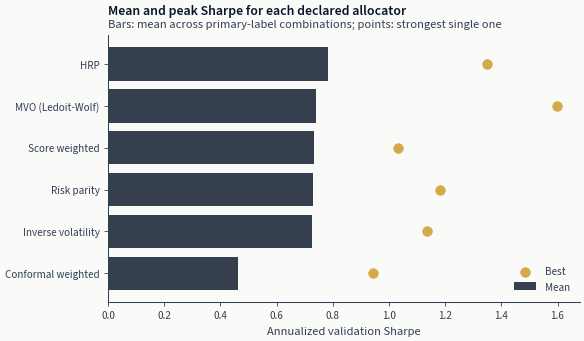

In [10]:
plot_alloc = alloc_comparison.sort("avg_sharpe")
fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
y = range(len(plot_alloc))
_ALLOCATOR_NAMES = {
    "inverse_vol": "Inverse volatility",
    "mvo_ledoit_wolf": "MVO (Ledoit-Wolf)",
    "hrp": "HRP",
}


def allocator_label(method: str) -> str:
    """Chart label for an allocator declared in `setup.yaml`."""
    return _ALLOCATOR_NAMES.get(method, method.replace("_", " ").capitalize())


labels = [allocator_label(name) for name in plot_alloc["allocator"].to_list()]
ax.barh(y, plot_alloc["avg_sharpe"], color=COLORS["blue"], alpha=0.82, label="Mean")
ax.scatter(plot_alloc["best_sharpe"], y, color=COLORS["amber"], s=48, zorder=3, label="Best")
ax.set_yticks(list(y), labels)
ax.set_xlabel("Annualized validation Sharpe")
ax.legend(frameon=False, loc="lower right")
add_message_title(
    ax,
    "Mean and peak Sharpe for each declared allocator",
    "Bars: mean across primary-label combinations; points: strongest single one",
)
fig.show()

## 4. Inspect the leading allocation

The table keeps the highest-Sharpe rows visible, and the figure after it shows whether that
result depends on one concentration choice. **Read the two together.** A row that leads at one
`top_k` and disappears at the next is a concentration artefact rather than an allocator that
suits this signal, and the sweep runs every level precisely so that is visible rather than
assumed.

In [11]:
top_rows = explorer.best(
    stage="allocation",
    top_n=10,
    label=ALLOCATION_LABEL,
    prediction_hashes=selected_hashes,
)
winner = explorer.inspect(top_rows["backtest_hash"][0])
winner_strategy = winner.spec["strategy"]
winner_allocator = winner_strategy["allocation"]["method"]
winner_top_k = winner_strategy["signal"]["top_k"]
baseline_sharpe = top_preds.filter(pl.col("prediction_hash") == winner.prediction_hash)["sharpe"][0]
allocation_delta = winner.metrics["sharpe"] - baseline_sharpe

print(
    f"Selected allocation: {winner.source}; allocator={winner_allocator}; "
    f"top_k={winner_top_k}; validation Sharpe={winner.metrics['sharpe']:.3f}"
)
print(f"Equal-weight baseline={baseline_sharpe:.3f}; allocation delta={allocation_delta:+.3f}")
top_rows.select("source", "prediction_hash", "sharpe", "cagr", "max_drawdown")

Selected allocation: latent_factors/sae; allocator=mvo_ledoit_wolf; top_k=5; validation Sharpe=1.600
Equal-weight baseline=0.939; allocation delta=+0.660


source,prediction_hash,sharpe,cagr,max_drawdown
str,str,f64,f64,f64
"""latent_factors/sae""","""603be304fcf3""",1.599784,1.020694,-0.470373
"""latent_factors/sae""","""603be304fcf3""",1.398315,0.809105,-0.48872
"""latent_factors/sae""","""603be304fcf3""",1.358258,0.716006,-0.437117
"""deep_learning/lstm_h64""","""803283c92aaf""",1.349193,0.610421,-0.280029
"""deep_learning/lstm_h64""","""803283c92aaf""",1.182682,0.507548,-0.368491
"""tabular_dl/tabm_s""","""0cccee8ba22c""",1.137761,0.683417,-0.637926
"""deep_learning/lstm_h64""","""803283c92aaf""",1.134641,0.480611,-0.38855
"""tabular_dl/tabm_s""","""0cccee8ba22c""",1.128231,0.792696,-0.667541
"""tabular_dl/tabm_s""","""0cccee8ba22c""",1.122208,0.714032,-0.668107


The point estimate is conditional on selecting this row from the full allocation sweep. An
ordinary interval for this one return path would omit that search, so it is not reported as
uncertainty about the selected allocation.

The curve below asks whether the allocation result depends on how many names are
held. A Sharpe that falls as the basket widens is what dilution of the
cross-sectional ranking looks like; one that is flat says the allocator, not the
concentration, is doing the work.

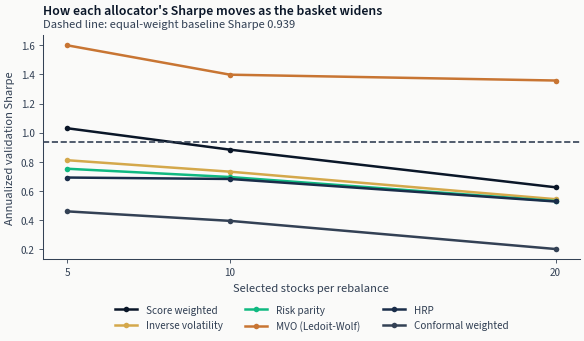

In [12]:
winner_curve = explorer.concentration_curve(winner.prediction_hash).filter(
    pl.col("allocator").is_in(allocation_methods)
)
palette = [
    COLORS["blue"],
    COLORS["amber"],
    COLORS["positive"],
    COLORS["copper"],
    COLORS["slate"],
    COLORS["neutral"],
][: len(allocation_methods)]

fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
for color, method in zip(palette, allocation_methods, strict=True):
    curve = winner_curve.filter(pl.col("allocator") == method).sort("top_k")
    ax.plot(
        curve["top_k"],
        curve["sharpe"],
        marker="o",
        linewidth=1.8,
        color=color,
        label=allocator_label(method),
    )
ax.axhline(baseline_sharpe, color=COLORS["neutral"], linestyle="--", linewidth=1.2)
ax.set_xticks(TOP_K_VALUES)
ax.set_xlabel("Selected stocks per rebalance")
ax.set_ylabel("Annualized validation Sharpe")
ax.legend(
    frameon=False,
    ncol=3,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
)
add_message_title(
    ax,
    "How each allocator's Sharpe moves as the basket widens",
    f"Dashed line: equal-weight baseline Sharpe {baseline_sharpe:.3f}",
)
fig.show()

## Key takeaways

1. **Equal weight is the baseline, not a competitor.** It is the signal stage's own weighting,
   so it is excluded from the allocator menu and the notebook raises if it reappears there.
   Every Sharpe here is read against it rather than ranked alongside it.

2. **An allocator is judged across concentration levels, not at one.** The method averages and
   the per-`top_k` figure answer different questions: which allocator suits this signal on
   average, and whether its leading row persists when the number of names held changes.

3. **The gain from allocation is measured against that lineage's own baseline.** The
   difference between a lineage's equal-weight Sharpe and its highest allocated Sharpe is
   what allocation contributed. That comparison holds the predictions fixed, which is what
   isolates the allocator's effect from the signal's.

4. **The declared allocators read three different things.** Score weighting reads the
   point prediction, `conformal_weighted` reads the width of its interval, and inverse
   volatility, risk parity, MVO and HRP weight by a moment of returns. Where the conformal
   intervals under-cover out of time - which `13_model_analysis` measures - only the
   interval-width allocator inherits that miscalibration, so read its result beside that
   coverage rather than on its own.

5. **These are selection-stage results on a current-constituent universe**, so they carry
   survivorship bias and establish no out-of-sample edge. The holdout is untouched here.

**Next:** [`16_risk_management`](16_risk_management.ipynb) applies friction to the leading validation lineage. See
Chapter 18 for the transaction-cost framework.